In [18]:
import importlib
import sys

# Reload the module to pick up any code changes
if 'vg_hubert' in sys.modules:
    importlib.reload(sys.modules['vg_hubert.simple_segmenter'])
    importlib.reload(sys.modules['vg_hubert'])

from vg_hubert import Segmenter
import matplotlib.pyplot as plt
import soundfile as sf
import torch
import librosa
from IPython.display import Audio
import numpy as np

## Syllable Segmentation

Just like Sylber, VG-HuBERT can be used with a simple interface:

In [19]:
# Loading VG-HuBERT for syllable segmentation
# Syllable mode uses best_bundle.pth, layer 8, sec_per_syllable=0.2, merge_threshold=0.3
# (following syllable-discovery repository recommendations)
segmenter = Segmenter(model_ckpt="../findsylls/models/vg-hubert_3", mode="syllable")

CUDA not available, using CPU


In [20]:
# Segment an audio file
wav_file = "../sylber/samples/sample.wav"  # Using Sylber's sample audio

outputs = segmenter(wav_file)
# or
# outputs = segmenter(wav=your_wav_array)

In [7]:
# Load audio for visualization
wav, sr = sf.read(wav_file)
Audio(data=wav, rate=sr)

### Visualize Syllable Segmentation

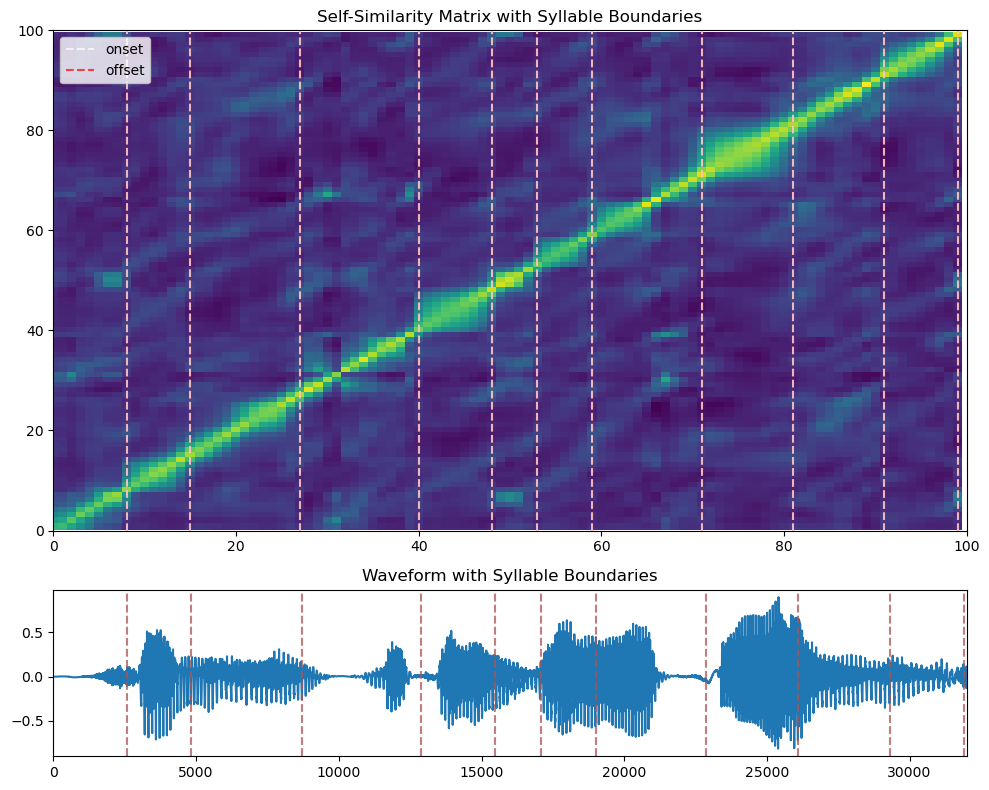


Found 14 syllables

First 5 syllables:
  1. 0.000s - 0.161s (duration: 0.161s)
  2. 0.161s - 0.302s (duration: 0.141s)
  3. 0.302s - 0.544s (duration: 0.242s)
  4. 0.544s - 0.806s (duration: 0.262s)
  5. 0.806s - 0.967s (duration: 0.161s)


In [21]:
# Plot self-similarity matrix and segments
frame_num = min(100, outputs['hidden_states'].shape[0])

f, (a0, a1) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [3, 1]}, figsize=(10, 8))

# Self-similarity matrix
ssm = outputs['hidden_states'] @ outputs['hidden_states'].T
a0.imshow(ssm[:frame_num, :frame_num], aspect='auto', cmap='viridis')
a0.set_title('Self-Similarity Matrix with Syllable Boundaries')

# Add syllable boundaries
need_legend = True
for s, e in outputs['segments']:
    s_frame = int(s * 50)  # Convert seconds to frames (50 fps)
    e_frame = int(e * 50)
    if s_frame < frame_num:
        a0.axvline(s_frame, color='white', ls='--', alpha=0.7, label='onset' if need_legend else '')
    if e_frame < frame_num:
        a0.axvline(e_frame, color='red', ls='--', alpha=0.7, label='offset' if need_legend else '')
    need_legend = False

if not need_legend:
    a0.legend()

a0.set_xlim(0, frame_num)
a0.set_ylim(0, frame_num)

# Waveform with boundaries
a1.plot(wav[:int(sr * frame_num / 50)])
a1.set_xlim(0, int(sr * frame_num / 50))
a1.set_title('Waveform with Syllable Boundaries')

for s, e in outputs['segments']:
    s_sample = int(s * sr)
    e_sample = int(e * sr)
    if s_sample < len(wav):
        a1.axvline(s_sample, color='gray', ls='--', alpha=0.5)
    if e_sample < len(wav):
        a1.axvline(e_sample, color='red', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nFound {len(outputs['segments'])} syllables")
print("\nFirst 5 syllables:")
for i, (s, e) in enumerate(outputs['segments'][:5], 1):
    print(f"  {i}. {s:.3f}s - {e:.3f}s (duration: {e-s:.3f}s)")

### Extract Segment Features

VG-HuBERT also provides segment-level feature embeddings:

Segment features shape: torch.Size([14, 768])
Number of segments: 14
Feature dimension: 768


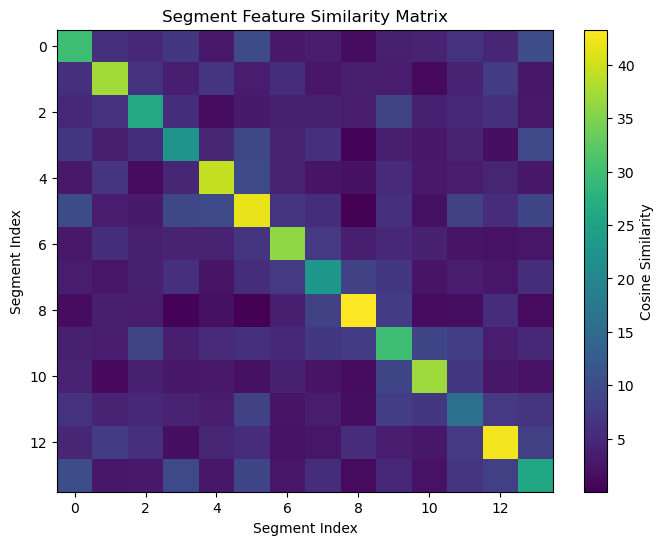

In [9]:
print(f"Segment features shape: {outputs['segment_features'].shape}")
print(f"Number of segments: {len(outputs['segments'])}")
print(f"Feature dimension: {outputs['segment_features'].shape[1]}")

# Visualize feature similarity
feat_sim = outputs['segment_features'] @ outputs['segment_features'].T
plt.figure(figsize=(8, 6))
plt.imshow(feat_sim, cmap='viridis', aspect='auto')
plt.colorbar(label='Cosine Similarity')
plt.title('Segment Feature Similarity Matrix')
plt.xlabel('Segment Index')
plt.ylabel('Segment Index')
plt.show()

## Word Segmentation

VG-HuBERT can perform word-level segmentation using CLS token attention weights.

**How it works**: Uses `snapshot_20.pth` (layer 9) and extracts attention from the CLS token. Peaks in CLS attention indicate word boundaries.

**No PyTorch patching needed**: Modern transformers with `attn_implementation='eager'` provides per-head attention weights natively.

In [22]:
# Load VG-HuBERT for word segmentation
# Word mode automatically uses snapshot_20.pth (layer 9) as recommended in syllable-discovery repo
word_segmenter = Segmenter(model_ckpt="../findsylls/models/vg-hubert_3", mode="word")

# Segment
word_outputs = word_segmenter(wav_file)

print(f"Found {len(word_outputs['segments'])} word-like units")
print("\nFirst 5 words:")
for i, (s, e) in enumerate(word_outputs['segments'][:5], 1):
    print(f"  {i}. {s:.3f}s - {e:.3f}s (duration: {e-s:.3f}s)")

CUDA not available, using CPU


Found 2 word-like units

First 5 words:
  1. 0.000s - 0.785s (duration: 0.785s)
  2. 0.785s - 2.840s (duration: 2.054s)


## Compare Syllable vs Word Segmentation

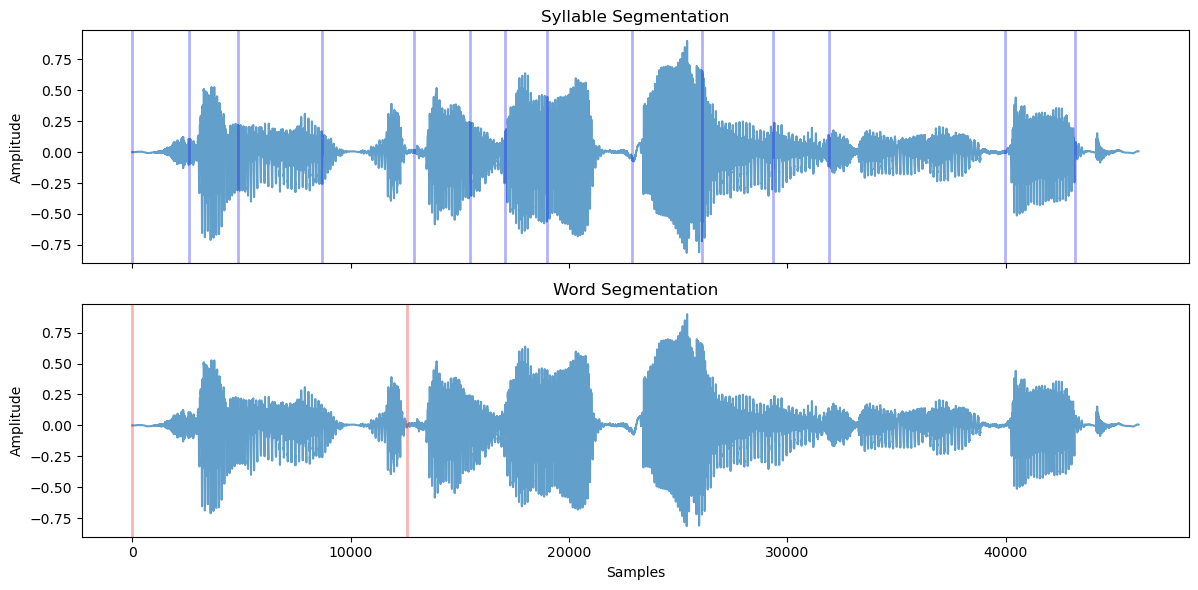

Syllables: 14
Words: 2
Average syllables per word: 7.00


In [23]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Syllable segmentation
ax1.plot(wav, alpha=0.7)
for s, e in outputs['segments']:
    ax1.axvline(s * sr, color='blue', alpha=0.3, linewidth=2)
ax1.set_title('Syllable Segmentation')
ax1.set_ylabel('Amplitude')

# Word segmentation
ax2.plot(wav, alpha=0.7)
for s, e in word_outputs['segments']:
    ax2.axvline(s * sr, color='red', alpha=0.3, linewidth=2)
ax2.set_title('Word Segmentation')
ax2.set_ylabel('Amplitude')
ax2.set_xlabel('Samples')

plt.tight_layout()
plt.show()

print(f"Syllables: {len(outputs['segments'])}")
print(f"Words: {len(word_outputs['segments'])}")
print(f"Average syllables per word: {len(outputs['segments']) / len(word_outputs['segments']):.2f}")

## Parameter Tuning

VG-HuBERT provides several parameters to tune segmentation:

In [12]:
# Adjust target syllable duration
segmenter_fast = Segmenter(
    model_ckpt="../findsylls/models/vg-hubert_3",
    mode="syllable",
    sec_per_syllable=0.15,  # Expect shorter syllables
    merge_threshold=0.3,     # Merge similar adjacent segments
    layer=8                  # Which HuBERT layer to use
)

outputs_fast = segmenter_fast(wav_file)
print(f"With sec_per_syllable=0.15: {len(outputs_fast['segments'])} syllables")

segmenter_slow = Segmenter(
    model_ckpt="../findsylls/models/vg-hubert_3",
    mode="syllable",
    sec_per_syllable=0.25,  # Expect longer syllables
    merge_threshold=0.4,     # More aggressive merging
    layer=8
)

outputs_slow = segmenter_slow(wav_file)
print(f"With sec_per_syllable=0.25: {len(outputs_slow['segments'])} syllables")

CUDA not available, using CPU
CUDA not available, using CPU


With sec_per_syllable=0.15: 16 syllables
With sec_per_syllable=0.25: 12 syllables


## Summary

VG-HuBERT now has a Sylber-like interface:

```python
from vg_hubert import Segmenter

# Syllable segmentation
segmenter = Segmenter(mode="syllable")
outputs = segmenter("audio.wav")

# Word segmentation
word_segmenter = Segmenter(mode="word")
word_outputs = word_segmenter("audio.wav")
```

Both return similar output formats with:
- `segments`: List of (start, end) tuples
- `segment_features`: Feature embeddings for each segment
- `hidden_states`: Frame-level hidden states